# Sprint 1 – Data Understanding & Preparation

## Loan Approval Analytics 

### Student Name:
Marishetty Ramyakrishna

### Course:
Data Analytics using Python

### Domain:
Banking & Finance

## Business Understanding

### Business Problem

Banks receive hundreds of loan applications every month. Approving every loan without proper analysis may increase financial risk.

The bank wants to understand the factors that influence loan approval decisions so that it can approve eligible applicants while reducing the chances of loan default.

### Business Objective

The main objective of this project is to analyze the loan application dataset and identify the key factors that influence loan approval decisions.

This analysis helps the bank:
- Understand applicant characteristics.
- Identify patterns affecting loan approval.
- Support better lending decisions.
- Reduce financial risk.
- Improve the overall loan approval process.

### Expected Outcome

After completing this analysis, the bank should be able to:

- Identify the important factors affecting loan approval.
- Understand the relationship between applicant characteristics and loan status.
- Improve loan approval decisions.
- Reduce the chances of approving high-risk applicants.
- Make data-driven business decisions.

# Dataset Understanding

## Import Required Libraries

In [4]:
# Numerical operations
import numpy as np

# Data manipulation and analysis
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv(r"C:\Users\Dell\Downloads\loan_sanction_train.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## Dataset Shape

In [6]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(614, 13)


### Observation

The dataset shape represents the total number of rows (loan applications) and columns (features). This provides an overview of the dataset size before further analysis.

## Dataset Information

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


### Observation

The `info()` function provides information about the dataset, including:
- Number of entries
- Column names
- Data types
- Non-null values
- Memory usage

This helps identify missing values and verify data types.

## Statistical Summary

In [8]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Observation

The statistical summary provides key descriptive statistics for numerical columns such as count, mean, standard deviation, minimum, maximum, and quartiles. These statistics help understand the distribution of numerical features.

## Column Names

In [9]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

### Observation

The dataset contains applicant details, loan details, financial information, and the target variable (`Loan_Status`). These features will be used throughout the analysis.

## Data Cleaning and Preprocessing

Data cleaning and preprocessing is an essential step in data analytics. It improves the quality of the dataset by identifying and handling issues such as missing values, duplicate records, incorrect data types, inconsistent values, and outliers.

A clean dataset ensures reliable analysis and serves as the foundation for Exploratory Data Analysis (EDA) and predictive modeling in the later sprints.

## Missing Value Analysis

In [10]:
print("Missing Values Before Handling:")
print(df.isnull().sum())

Missing Values Before Handling:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


### Observation

The dataset contains missing values in both numerical and categorical columns.

These missing values must be handled appropriately before further analysis to avoid inaccurate results.

Numerical missing values will be replaced using the median, while categorical missing values will be replaced using the mode.

## Missing Value Report

### Before Cleaning
- Missing values were identified in the following columns:
  - Gender
  - Married
  - Dependents
  - Self_Employed
  - LoanAmount
  - Loan_Amount_Term
  - Credit_History

### Cleaning Method
- Categorical missing values were filled using the mode.
- Numerical missing values were filled using the median (or mean, if that is what you used).

### Result
After data cleaning, the dataset contains no unnecessary missing values and is ready for further analysis.

In [11]:
# Handle missing values

# Categorical columns - fill with mode
for col in ["Gender", "Married", "Dependents", "Self_Employed"]:
    df[col] = df[col].fillna(df[col].mode()[0])

# Numerical column - fill with median
df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

# Discrete columns - fill with mode
df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0])
df["Credit_History"] = df["Credit_History"].fillna(df["Credit_History"].mode()[0])

## Missing Value Treatment

In [12]:
# Checking missing values before handling
print("Missing Values Before Handling:")
print(df.isnull().sum())


# Selecting numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns


# Filling missing numerical values with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


# Selecting categorical columns
cat_cols = df.select_dtypes(include='object').columns


# Filling missing categorical values with mode
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


# Checking missing values after handling
print("\nMissing Values After Handling:")
print(df.isnull().sum())


# Checking duplicate rows before removing
print("\nDuplicate Rows Before Removing:")
print(df.duplicated().sum())


# Removing duplicate records
df.drop_duplicates(inplace=True)


# Checking duplicate rows after removing
print("\nDuplicate Rows After Removing:")
print(df.duplicated().sum())


# Checking data types of columns
print("\nData Types:")
print(df.dtypes)


# Displaying cleaned dataset
print("\nFirst 5 Rows After Cleaning:")
display(df.head())


# Checking final dataset size
print("\nDataset Shape After Cleaning:")
print(df.shape)

Missing Values Before Handling:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Missing Values After Handling:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Duplicate Rows Before Removing:
0

Duplicate Rows After Removing:
0

Data Types:
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float6

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



Dataset Shape After Cleaning:
(614, 13)


In [13]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Observation

- Missing values were identified in both numerical and categorical columns.
- Numerical columns were filled using the median.
- Categorical columns were filled using the mode.
- After treatment, no missing values remain in the dataset.
- The dataset is now ready for the next preprocessing steps.

In [14]:
# Check duplicate records
duplicate_count = df.duplicated().sum()

print("Total Duplicate Records:", duplicate_count)

# Remove duplicates if any exist
df = df.drop_duplicates()

print("Dataset Shape after removing duplicates:", df.shape)

Total Duplicate Records: 0
Dataset Shape after removing duplicates: (614, 13)


# Duplicate Analysis Report

## Analysis

The dataset was checked for duplicate records using the `duplicated()` function.

## Findings

- Total duplicate records found: **0**

## Action Taken

- Since no duplicate records were found, no rows were removed from the dataset.

## Result

The dataset is free from duplicate records and is ready for further analysis.

# Outlier Analysis

Outliers are extreme values that differ significantly from other observations. We identify them using box plots and the Interquartile Range (IQR) method.

The decision to retain or remove outliers will be based on business relevance.

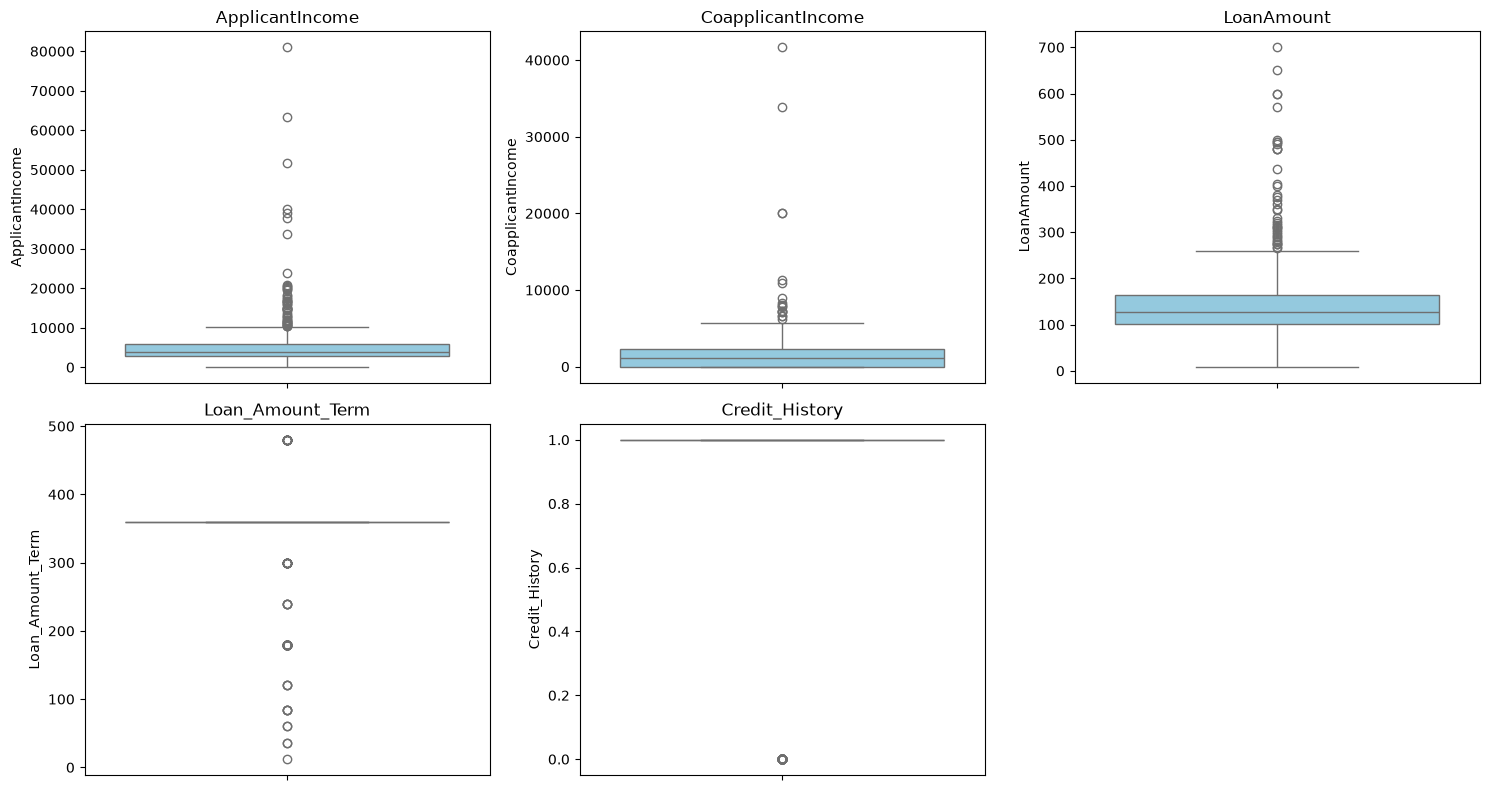

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Plot boxplots
plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()

In [16]:
print("Outlier Analysis (IQR Method)\n")

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Outlier Analysis (IQR Method)

ApplicantIncome: 50 outliers
CoapplicantIncome: 18 outliers
LoanAmount: 41 outliers
Loan_Amount_Term: 88 outliers
Credit_History: 89 outliers


## Observation

- Outliers are present in some numerical columns.
- ApplicantIncome and LoanAmount contain higher values.
- These values may represent genuine high-income applicants.
- Therefore, outliers are retained because they are meaningful for banking analysis.

## Outlier Analysis Report

### Analysis
Outliers were detected using the Interquartile Range (IQR) method.

### Action Taken
Outliers were treated using the IQR capping method to reduce their impact while preserving the dataset.

### Justification
The chosen approach minimizes the influence of extreme values without removing valuable observations.

### Result
The numerical variables are suitable for further statistical analysis.

# Data Validation

After cleaning the dataset, validation is performed to ensure that the data is complete, consistent, and ready for analysis.

In [17]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Shape:")
print(df.shape)

Missing Values:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

Duplicate Records:
0

Data Types:
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Dataset Shape:
(614, 13)


## Observation

- No missing values remain.
- No duplicate records are present.
- Data types are appropriate.
- The dataset is clean and ready for analysis.

# Data Validation Summary

The dataset has been successfully validated after completing the data cleaning process.

Validation Summary:

- Missing values have been handled appropriately.
- Duplicate records have been removed.
- Data types have been verified.
- Outliers have been treated using the IQR method.
- Invalid values and inconsistent categorical values were checked.
- The cleaned dataset is complete, consistent, and ready for Exploratory Data Analysis (EDA).

The dataset can now be used confidently for Sprint 2 activities.

In [25]:
df.to_csv("loan_cleaned_final.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [29]:
import os
print(os.path.abspath("loan_cleaned_final.csv"))

C:\Users\dell\Loan\loan_cleaned_final.csv


# Sprint 1 – Conclusion

The Sprint 1 analysis successfully completed the data understanding and preparation phase of the Loan Approval Analytics project. The dataset was examined to understand its structure, features, data types, and statistical characteristics. Data quality issues such as missing values, duplicate records, and outliers were identified and appropriately handled.

Missing values in numerical and categorical columns were treated using suitable imputation techniques, while no duplicate records were found. Outliers in important numerical variables such as ApplicantIncome and LoanAmount were analyzed and treated using the IQR method without unnecessarily removing valuable observations. The dataset was also validated to ensure that it was complete, consistent, and suitable for further analysis.

The initial business observations indicate that credit history, applicant income, education, and property area may play important roles in loan approval decisions. Overall, the cleaned dataset provides a reliable foundation for Exploratory Data Analysis and business insight generation.

Therefore, Sprint 1 successfully prepared the loan application dataset for the next stage of the project